# EX 3 – Baseball Databank

Same preprocessing workflow as the friend's EX 3: missing values, duplicates, outliers, normalization and categorical encoding, adapted to Batting.csv.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

batting = pd.read_csv(find_data("Batting.csv"))

print("Baseball dataset loaded successfully.")
print("Shape:", batting.shape)
print("Columns:", len(batting.columns))

Baseball dataset loaded successfully.
Shape: (101332, 22)
Columns: 22


In [3]:
print("Columns:")
print(batting.columns.tolist())

print("\nFirst five records:")
display(batting.head())

Columns:
['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']

First five records:


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,0.0,0.0,13.0,8.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,5.0,0.0,19.0,3.0,1.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,2.0,2.0,27.0,1.0,1.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,3.0,0.0,16.0,6.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Missing-value count by column:")
missing_values = batting.isnull().sum()
display(missing_values.to_frame("Missing Values"))
print("Total missing values:", int(missing_values.sum()))

Missing-value count by column:


,Missing Values
playerID,0
yearID,0
stint,0
teamID,0
lgID,737
G,0
AB,5149
R,5149
H,5149
2B,5149


Total missing values: 223988


In [5]:
batting_clean = batting.copy()

numeric_cols = batting_clean.select_dtypes(include=np.number).columns
categorical_cols = batting_clean.select_dtypes(include=["object", "category"]).columns

for col in numeric_cols:
    if batting_clean[col].isnull().any():
        batting_clean[col] = batting_clean[col].fillna(batting_clean[col].mean())

for col in categorical_cols:
    if batting_clean[col].isnull().any():
        mode_value = batting_clean[col].mode()
        if not mode_value.empty:
            batting_clean[col] = batting_clean[col].fillna(mode_value.iloc[0])

print("Total missing values before:", int(batting.isnull().sum().sum()))
print("Total missing values after:", int(batting_clean.isnull().sum().sum()))

Total missing values before: 223988
Total missing values after: 0


In [6]:
comparison = pd.DataFrame({
    "Before Cleaning": batting.isnull().sum(),
    "After Cleaning": batting_clean.isnull().sum()
})
display(comparison)

,Before Cleaning,After Cleaning
playerID,0,0
yearID,0,0
stint,0,0
teamID,0,0
lgID,737,0
G,0,0
AB,5149,0
R,5149,0
H,5149,0
2B,5149,0


In [7]:
duplicate_count = int(batting_clean.duplicated().sum())
print("Duplicate rows before removal:", duplicate_count)

batting_clean = batting_clean.drop_duplicates().copy()

print("Duplicate rows after removal:", int(batting_clean.duplicated().sum()))
print("Cleaned dataset shape:", batting_clean.shape)

Duplicate rows before removal: 0


Duplicate rows after removal: 0
Cleaned dataset shape: (101332, 22)


In [8]:
outlier_col = "R"

q1 = batting[outlier_col].quantile(0.25)
q3 = batting[outlier_col].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = batting[(batting[outlier_col] < lower) | (batting[outlier_col] > upper)]

print("Column selected:", outlier_col)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

display(outliers.head(10))

Column selected: R
Q1: 0.0
Q3: 30.0
IQR: 30.0
Lower limit: -45.0
Upper limit: 75.0
Number of outliers: 7026


,playerID,yearID,stint,teamID,lgID,G,AB,R,H,2B,3B,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
124,barnero01,1872,1,BS1,NaN,45,229.0,81.0,99.0,28.0,2.0,1.0,44.0,12.0,2.0,9.0,4.0,NaN,NaN,NaN,NaN,NaN
154,cuthbne01,1872,1,PH1,NaN,47,260.0,83.0,88.0,10.0,0.0,1.0,47.0,14.0,4.0,6.0,10.0,NaN,NaN,NaN,NaN,NaN
158,eggleda01,1872,1,NY2,NaN,56,290.0,94.0,98.0,20.0,0.0,0.0,20.0,18.0,5.0,8.0,9.0,NaN,NaN,NaN,NaN,NaN
181,hatfijo01,1872,1,NY2,NaN,56,288.0,76.0,92.0,15.0,1.0,1.0,45.0,12.0,5.0,9.0,6.0,NaN,NaN,NaN,NaN,NaN
265,wrighge01,1872,1,BS1,NaN,48,255.0,87.0,86.0,16.0,6.0,2.0,32.0,14.0,4.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN
280,barnero01,1873,1,BS1,NaN,60,322.0,125.0,137.0,29.0,8.0,2.0,62.0,13.0,4.0,18.0,2.0,NaN,NaN,NaN,NaN,NaN
296,careyto01,1873,1,BL1,NaN,56,290.0,76.0,97.0,19.0,3.0,1.0,55.0,1.0,3.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN
302,cuthbne01,1873,1,PH2,NaN,51,278.0,78.0,77.0,5.0,3.0,2.0,33.0,13.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN
307,eggleda01,1873,1,NY2,NaN,53,268.0,82.0,90.0,13.0,4.0,0.0,34.0,4.0,1.0,5.0,2.0,NaN,NaN,NaN,NaN,NaN
314,forceda01,1873,1,BL1,NaN,49,234.0,77.0,86.0,8.0,1.0,0.0,31.0,1.0,0.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN


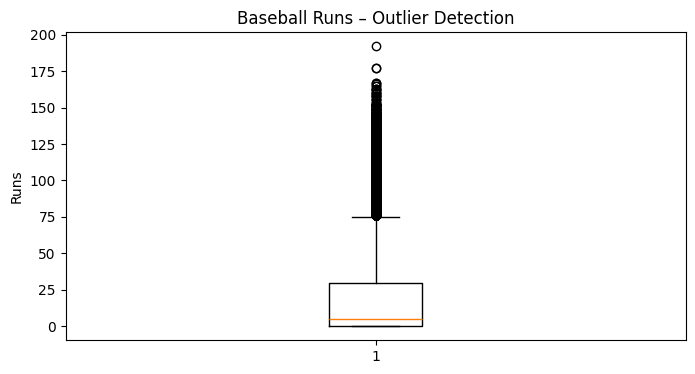

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(batting[outlier_col].dropna())
plt.title("Baseball Runs – Outlier Detection")
plt.ylabel("Runs")
plt.show()

In [10]:
scaler = MinMaxScaler()
batting_transformed = batting_clean.copy()

batting_transformed["R_normalized"] = scaler.fit_transform(
    batting_transformed[["R"]]
)

display(batting_transformed[["R", "R_normalized"]].head(10))

print("Minimum normalized value:", batting_transformed["R_normalized"].min())
print("Maximum normalized value:", batting_transformed["R_normalized"].max())

,R,R_normalized
0,0.0,0.000000
1,30.0,0.156250
2,28.0,0.145833
3,28.0,0.145833
4,29.0,0.151042
5,9.0,0.046875
6,0.0,0.000000
7,66.0,0.343750
8,1.0,0.005208
9,13.0,0.067708


Minimum normalized value: 0.0
Maximum normalized value: 1.0


In [11]:
encoder = LabelEncoder()
batting_transformed["teamID_encoded"] = encoder.fit_transform(
    batting_transformed["teamID"].astype(str)
)

print("Column encoded: teamID")
print("Number of categories:", len(encoder.classes_))
print("First five category mappings:")
print(dict(zip(encoder.classes_[:5], encoder.transform(encoder.classes_[:5]))))

display(
    batting_transformed[["teamID", "teamID_encoded"]].drop_duplicates()
    .sort_values("teamID_encoded").head(10)
)

Column encoded: teamID
Number of categories: 149
First five category mappings:
{'ALT': np.int64(0), 'ANA': np.int64(1), 'ARI': np.int64(2), 'ATL': np.int64(3), 'BAL': np.int64(4)}


,teamID,teamID_encoded
2019,ALT,0
75406,ANA,1
76634,ARI,2
44960,ATL,3
36874,BAL,4
1056,BFN,5
4494,BFP,6
146,BL1,7
1441,BL2,8
4490,BL3,9


In [12]:
one_hot = pd.get_dummies(
    batting_clean[["teamID"]].astype(str),
    prefix="teamID"
)

print("One-hot encoded shape:", one_hot.shape)
display(one_hot.head(10))

One-hot encoded shape: (101332, 149)


,teamID_ALT,teamID_ANA,teamID_ARI,teamID_ATL,teamID_BAL,teamID_BFN,teamID_BFP,teamID_BL1,teamID_BL2,teamID_BL3,teamID_BL4,teamID_BLA,teamID_BLF,teamID_BLN,teamID_BLU,teamID_BOS,teamID_BR1,teamID_BR2,teamID_BR3,teamID_BR4,teamID_BRF,teamID_BRO,teamID_BRP,teamID_BS1,teamID_BS2,teamID_BSN,teamID_BSP,teamID_BSU,teamID_BUF,teamID_CAL,teamID_CH1,teamID_CH2,teamID_CHA,teamID_CHF,teamID_CHN,teamID_CHP,teamID_CHU,teamID_CIN,teamID_CL1,teamID_CL2,...,teamID_PTP,teamID_RC1,teamID_RC2,teamID_RIC,teamID_SDN,teamID_SE1,teamID_SEA,teamID_SFN,teamID_SL1,teamID_SL2,teamID_SL3,teamID_SL4,teamID_SL5,teamID_SLA,teamID_SLF,teamID_SLN,teamID_SLU,teamID_SPU,teamID_SR1,teamID_SR2,teamID_TBA,teamID_TEX,teamID_TL1,teamID_TL2,teamID_TOR,teamID_TRN,teamID_TRO,teamID_WAS,teamID_WIL,teamID_WOR,teamID_WS1,teamID_WS2,teamID_WS3,teamID_WS4,teamID_WS5,teamID_WS6,teamID_WS7,teamID_WS8,teamID_WS9,teamID_WSU
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

In [13]:
summary = pd.DataFrame([{
    "Original Rows": len(batting),
    "Cleaned Rows": len(batting_clean),
    "Duplicate Rows Removed": duplicate_count,
    "Missing Values Before": int(batting.isnull().sum().sum()),
    "Missing Values After": int(batting_clean.isnull().sum().sum()),
    "Outlier Column": outlier_col,
    "Outliers Detected": int(len(outliers)),
    "Normalized Column": "R",
    "Encoded Column": "teamID"
}])

display(summary)

,Original Rows,Cleaned Rows,Duplicate Rows Removed,Missing Values Before,Missing Values After,Outlier Column,Outliers Detected,Normalized Column,Encoded Column
0,101332,101332,0,223988,0,R,7026,R,teamID
